In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [229]:
dataset = pd.read_csv("customer_acquisition_data.csv")

In [230]:
dataset

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419
...,...,...,...,...,...
795,796,social media,9.546326,0.167592,2813
796,797,email marketing,5.246263,0.043822,3439
797,798,social media,9.546326,0.167592,2101
798,799,paid advertising,30.450327,0.016341,813


In [231]:
dataset.isna().sum()

,0
customer_id,0
channel,0
cost,0
conversion_rate,0
revenue,0


In [232]:
dataset.duplicated().sum()

np.int64(0)

In [233]:
dataset['revenue'].sort_values(ascending=True)

,revenue
639,500
336,500
459,510
720,513
463,516
...,...
431,4954
334,4956
253,4994
406,4998


In [234]:
summary = (
    dataset.groupby("channel")
      .agg(
          avg_cost=("cost", "mean"),
          avg_conversion_rate=("conversion_rate", "mean"),
          avg_revenue=("revenue", "mean")
      )
      .reset_index()
)


In [235]:
summary["expected_revenue_per_lead"]= summary['avg_conversion_rate'] * summary['avg_revenue']
summary["net_profit_per_lead"]= summary["expected_revenue_per_lead"] - summary['avg_cost'] # here we make output for Net profit for each channel
summary = summary.sort_values("net_profit_per_lead", ascending=False)


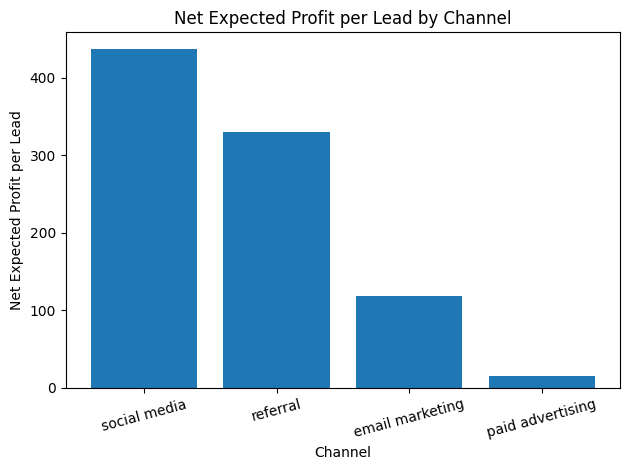

In [236]:
plt.figure()
plt.bar(summary['channel'], summary["net_profit_per_lead"])
plt.xlabel("Channel")
plt.ylabel("Net Expected Profit per Lead")
plt.title("Net Expected Profit per Lead by Channel")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [237]:
X = dataset.iloc[: , 1:4].to_numpy()

margin = ((dataset["revenue"] - dataset["cost"]) / dataset["cost"]).to_numpy()

In [238]:
X

array([['referral', 8.320326732170223, 0.1231449787166301],
       ['paid advertising', 30.450327213520207, 0.0163414915688768],
       ['email marketing', 5.2462632712450965, 0.0438222285949381],
       ...,
       ['social media', 9.546325667652964, 0.1675922473559195],
       ['paid advertising', 30.450327213520207, 0.0163414915688768],
       ['email marketing', 5.2462632712450965, 0.0438222285949381]],
      dtype=object)

In [239]:
margin

array([503.66768135, 110.98566032, 602.09592493, 158.22356443,
       289.73377499, 125.63246516, 121.76974836, 132.42830198,
       222.85576131, 101.86680281, 571.40741548, 173.87294031,
       353.90094492, 677.9594452 , 136.85516326,  41.79100158,
       173.9931279 , 148.39084129, 214.16131667, 532.51270243,
        63.89257032, 762.2098873 , 209.55221349, 748.48583338,
       358.30335603, 145.30384655, 891.2541165 , 194.57262815,
       826.63669597,  44.48391189, 388.28759702, 151.83367138,
       241.89911503, 202.95281575,  65.5345888 , 573.01591954,
       400.82999549, 331.2744384 , 158.14443106, 463.88558977,
       412.45750579, 116.11312173, 108.22706928,  31.97173107,
       117.09396907, 109.19946696, 659.66070664,  98.99607308,
       163.9849434 ,  67.62711266, 372.98046925,  83.49827097,
       432.035879  , 286.24833494,  95.84624994,  22.61222574,
       523.94506234,  21.13440911, 103.32282625,  58.30970749,
       660.8043778 ,  81.96385725, 740.48013527, 431.73

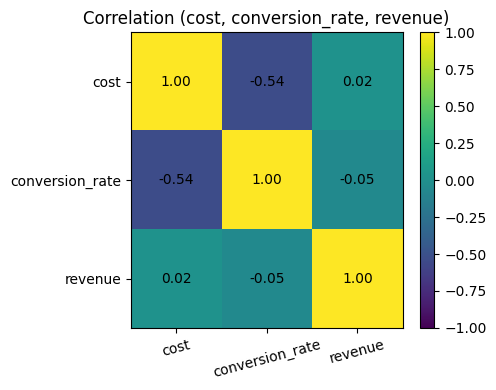

In [240]:
num_corr = dataset[["cost", "conversion_rate", "revenue"]].corr()

plt.figure(figsize=(5,4))
plt.imshow(num_corr.values, vmin=-1, vmax=1, aspect="auto")
plt.colorbar()
plt.title("Correlation (cost, conversion_rate, revenue)")
plt.xticks(range(3), ["cost","conversion_rate","revenue"], rotation=15)
plt.yticks(range(3), ["cost","conversion_rate","revenue"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{num_corr.values[i,j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test= train_test_split(X, margin, test_size=0.25 , random_state=0)

thr = np.quantile(y_train, 0.75)      
y_train = (y_train >= thr).astype(np.int32)  
y_test  = (y_test  >= thr).astype(np.int32)

In [242]:
X_train

array([['social media', 9.546325667652964, 0.1675922473559195],
       ['paid advertising', 30.450327213520207, 0.0163414915688768],
       ['social media', 9.546325667652964, 0.1675922473559195],
       ...,
       ['email marketing', 5.2462632712450965, 0.0438222285949381],
       ['social media', 9.546325667652964, 0.1675922473559195],
       ['referral', 8.320326732170223, 0.1231449787166301]], dtype=object)

In [243]:
X_test

array([['paid advertising', 30.450327213520207, 0.0163414915688768],
       ['referral', 8.320326732170223, 0.1231449787166301],
       ['referral', 8.320326732170223, 0.1231449787166301],
       ['social media', 9.546325667652964, 0.1675922473559195],
       ['referral', 8.320326732170223, 0.1231449787166301],
       ['paid advertising', 30.450327213520207, 0.0163414915688768],
       ['social media', 9.546325667652964, 0.1675922473559195],
       ['referral', 8.320326732170223, 0.1231449787166301],
       ['social media', 9.546325667652964, 0.1675922473559195],
       ['referral', 8.320326732170223, 0.1231449787166301],
       ['referral', 8.320326732170223, 0.1231449787166301],
       ['referral', 8.320326732170223, 0.1231449787166301],
       ['email marketing', 5.2462632712450965, 0.0438222285949381],
       ['social media', 9.546325667652964, 0.1675922473559195],
       ['social media', 9.546325667652964, 0.1675922473559195],
       ['paid advertising', 30.450327213520207, 0.0163

In [244]:
# from sklearn.preprocessing import StandardScaler
# sc = StandardScaler()
# X_train[:, 1:]= sc.fit_transform(X_train[:, 1:])
# X_test[:, 1:]= sc.transform(X_test[:, 1:])


In [245]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(
    [("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [0])],
    remainder="passthrough"
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [246]:
X_train

array([[0.0, 0.0, 0.0, 1.0, 9.546325667652964, 0.1675922473559195],
       [0.0, 1.0, 0.0, 0.0, 30.450327213520207, 0.0163414915688768],
       [0.0, 0.0, 0.0, 1.0, 9.546325667652964, 0.1675922473559195],
       ...,
       [1.0, 0.0, 0.0, 0.0, 5.2462632712450965, 0.0438222285949381],
       [0.0, 0.0, 0.0, 1.0, 9.546325667652964, 0.1675922473559195],
       [0.0, 0.0, 1.0, 0.0, 8.320326732170223, 0.1231449787166301]],
      dtype=object)

In [247]:
X_test

array([[0.0, 1.0, 0.0, 0.0, 30.450327213520207, 0.0163414915688768],
       [0.0, 0.0, 1.0, 0.0, 8.320326732170223, 0.1231449787166301],
       [0.0, 0.0, 1.0, 0.0, 8.320326732170223, 0.1231449787166301],
       ...,
       [1.0, 0.0, 0.0, 0.0, 5.2462632712450965, 0.0438222285949381],
       [0.0, 1.0, 0.0, 0.0, 30.450327213520207, 0.0163414915688768],
       [0.0, 0.0, 0.0, 1.0, 9.546325667652964, 0.1675922473559195]],
      dtype=object)

In [248]:
# from sklearn.linear_model import LogisticRegression
# classifier = LogisticRegression(random_state = 0)
# classifier.fit(X_train, y_train)

In [249]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=0, n_jobs=-1).fit(X_train, y_train)


In [253]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))


[[0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]

In [254]:
from sklearn.metrics import accuracy_score,confusion_matrix
ac = accuracy_score(y_test,y_pred)
cm= confusion_matrix(y_test,y_pred)
ac


0.79

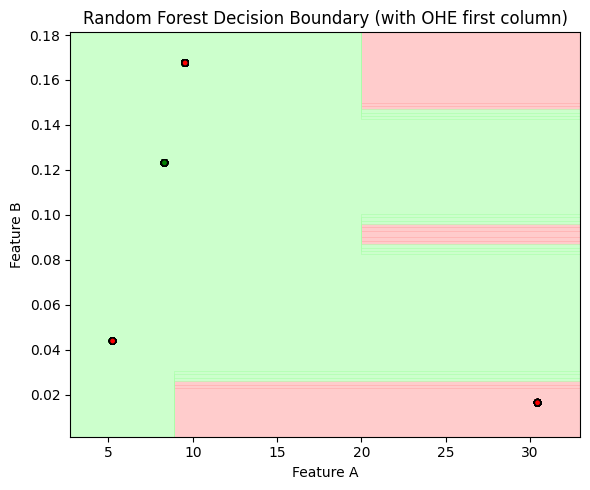

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

enc = ct.named_transformers_["encode"]
K = enc.categories_[0].size           
num_i, num_j = K, K+1                 
most_common_ohe_col = np.argmax(X_train[:, :K].sum(axis=0))

x_min, x_max = X_train[:, num_i].min(), X_train[:, num_i].max()
y_min, y_max = X_train[:, num_j].min(), X_train[:, num_j].max()
pad_x = 0.1 * (x_max - x_min + 1e-9)
pad_y = 0.1 * (y_max - y_min + 1e-9)

X1, X2 = np.meshgrid(
    np.arange(x_min - pad_x, x_max + pad_x, 0.01),
    np.arange(y_min - pad_y, y_max + pad_y, 0.01)
)

grid = np.zeros((X1.size, K + 2), dtype=float)
grid[:, most_common_ohe_col] = 1.0    
grid[:, num_i] = X1.ravel()
grid[:, num_j] = X2.ravel()

Z = classifier.predict(grid).reshape(X1.shape)

plt.figure(figsize=(6,5))
plt.contourf(X1, X2, Z, alpha=0.6, cmap=ListedColormap(['#FFAAAA', '#AAFFAA']))
plt.scatter(X_train[:, num_i], X_train[:, num_j], c=y_train, edgecolor='k',
            s=20, cmap=ListedColormap(['red','green']))
plt.xlabel('Feature A')   
plt.ylabel('Feature B')
plt.title('Random Forest Decision Boundary (with OHE first column)')
plt.tight_layout()
plt.show()
